# Améliorer les résultats d'une régression

On va continuer avec l'exemple de régression pour prédire **le nombre de views de Mr.Beast**.

On a un premier modèle, mais on peut clairement améliorer les résultats...

Voici des pistes de solutions :

1. **Régression à plusieurs variables** : combiner à la fois les données de commentaires et de likes
2. **Revoir le jeu de données pour vérifier si on peut ajouter plus d'information** : on a mis de côté pas mal de colonnes, on peut retourner voir ce qui est utilisable
3. **Aller plus loin qu'une droite** : tester une régression *non-linéaire*

In [1]:
#@title Importation des bibliothèques et du jeu de données
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.graph_objects import Figure

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor

iris = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/master/iris.csv")
df_mr_beast = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/master/MrBeast_youtube_stats-simple.csv")
display(iris)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


**On va toujours refaire la même chose : modifier le DataFrame, puis entraîner le modèle et regarder le résultat.**

On va reprendre la fonction du dernier chapitre qui fait ça :

In [2]:
#@title Fonction qui crée et entraîne un modèle

def entrainer_et_evaluer(modele, df, colonne_a_predire, random_state=25):
  # 1. On sépare les données en entraînement/validation
  df_entrainement, df_test = train_test_split(df, random_state=random_state, test_size=0.25)

  # X = tout sauf la colonne_a_predire
  X_entrainement = df_entrainement.drop(colonne_a_predire, axis='columns')
  # y = seulement la colonne_a_predire
  y_entrainement = df_entrainement[colonne_a_predire]

  X_test = df_test.drop(colonne_a_predire, axis='columns')
  y_test = df_test[colonne_a_predire]

  # 2. Le modèle doit déjà avoir été créé et passé en paramètre à la fonction
  # modele = LinearRegression()

  # 3. Entraîner
  modele.fit(X_entrainement, y_entrainement)

  y_predictions_entrainement = modele.predict(X_entrainement)
  y_predictions_test = modele.predict(X_test)

  rmse_entrainement = root_mean_squared_error(y_entrainement, y_predictions_entrainement)
  rmse_validation = root_mean_squared_error(y_test, y_predictions_test)

  # On retourne les erreurs RMSE d'entraînement et de validation pour les évaluer
  return [rmse_entrainement, rmse_validation]

## Comparer différents modèles et choisir le meilleur : *entraînement-validation-test*

On a fait ça vite fait au dernier module : on a comparé la performance de deux modèles différents pour voir lequel était le meilleur.

On a regardé la performance d'un modèle basé sur les likes vs la performance d'un autre basé sur les commentaires.

**On va refaire ça avec quelques autres possibilités de modèles pour trouver le meilleur.**

&nbsp;

Il y avait cependant un petit problème avec notre approche...

**Dès qu'on utilise des données dans le processus de sélection d'une IA, notre modèle devient biaisé en faveur de ces données.**

Ça inclut :

- L'entraînement
- Choisir entre deux colonnes
- Choisir un algorithme (ex.: KNN vs régression linéaire)
- Normaliser les données
- etc

&nbsp;

Pour avoir un vrai estimé de si notre modèle est bon ou pas, il va falloir faire une évaluation finale sur **des nouvelles données qui n'ont jamais été vues pendant la démarche**.

Voyez ça comme une simulation finale du monde réel.

On va avoir besoin de **trois sous-ensembles du jeu de données** :

1. L'ensemble d'**entraînement** : les données utilisées pour entraîner l'algorithme
2. L'ensemble de **validation** : on va tester chaque algorithme entraînement sur ces données, qui n'auront pas été vues pendant l'entraînement
3. L'ensemble **test final** : ces dernières données sont ***sacrées***. On les regarde uniquement quand on est 100% sûrs de notre choix de modèle

Si on se limitait à regarder la performance de notre modèle final sur l'ensemble de validation (celui qui a servi à choisir quel modèle on veut), on se retrouverait à surestimer la capacité du modèle. On aurait tendence à avoir choisir un modèle qui est *légèrement meilleur que les autres sur ces données spécifiques*.

Tout cela étant dit, on peut déjà mettre de côté des données qu'on ne devra pas toucher avant la fin du calepin :

In [3]:
#@title Séparation du jeu de données en trois
if len(df_mr_beast) == 928:
  df_mr_beast, df_mr_beast_test_final = train_test_split(
      df_mr_beast,
      random_state=25,
      test_size=0.2)

  print("Données pour l'entraînement et la validation:", len(df_mr_beast))
  print("Données gardées de côté pour le test final:", len(df_mr_beast_test_final))
else:
  print("Données déjà séparées")
  print("Redémarrez le notebook et exécutez toutes les cellules si vous avez besoin de réexécuter ceci")

Données pour l'entraînement et la validation: 742
Données gardées de côté pour le test final: 186


In [4]:
#@title Nettoyage du jeu de données
df_mr_beast_nettoye = df_mr_beast[['viewCount', 'likeCount', 'commentCount']]
df_mr_beast_nettoye = df_mr_beast_nettoye.dropna()
display(df_mr_beast_nettoye)

,viewCount,likeCount,commentCount
121,51442.0,1567.0,351.0
221,140195.0,3128.0,604.0
152,260734.0,4164.0,400.0
140,142738.0,3350.0,403.0
671,245170147.0,5626251.0,127574.0
...,...,...,...
317,127239.0,5071.0,453.0
143,140579.0,4906.0,656.0
474,24548088.0,632131.0,29044.0
318,47749.0,1604.0,146.0


## Option 1: Régression linéaire multiple

Au dernier module, on a choisi entre deux options : utiliser les likes *ou* utiliser les commentaires. Pourquoi pas les deux?

&nbsp;

On peut généraliser la régression linéaire **à plusieurs dimensions**.

Plutôt que d'utiliser une simple droite :

$$y = m*x + b$$

on peut chercher un mélange de deux ou de plus plusieurs variables :

$$y = m_1 * x_1 + m_2 * x_2 + b$$

&nbsp;

- Une seule variable utilisée pour en prédire une deuxième, l'équation correspond à **une droite**.
- À deux variables qui en prédisent une troisième, c'est l'équation  d'**un plan en 3D**.
- À plus de variables que ça, on appelle ça un hyperplan (et ça fait mal au cerveau essayer d'imaginer ce que ça donne)

&nbsp;

Voici ce que ça donnerait sur iris si on tentait d'apprendre à prédire :

$$\text{petal_length} = m_1 * \text{petal_width} + m_2 * \text{sepal_length} + b$$

In [5]:
#@title Démonstration sur iris
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def demo():
  iris_entrainement, iris_test = train_test_split(iris, random_state=25, test_size=0.25)

  # 1. Séparer le jeu de données pour l'entraînement et l'évaluation (entrainement/test)
  X_entrainement = iris_entrainement[['petal_width', 'sepal_length']]
  y_entrainement = iris_entrainement['petal_length']
  X_test = iris_test[['petal_width', 'sepal_length']]
  y_test = iris_test['petal_length']

  ### 2. Créer le modèle
  modele = LinearRegression()

  ### 3. Entraîner le modèle sur les données d'entraînement avec .fit()
  modele.fit(X_entrainement, y_entrainement)

  ### 4. Évaluer le résultat avec root_mean_squared_error()
  y_predictions_entrainement = modele.predict(X_entrainement)
  y_predictions_test = modele.predict(X_test)

  print("RMSE entrainement:", root_mean_squared_error(y_entrainement, y_predictions_entrainement))
  print("RMSE validation:", root_mean_squared_error(y_test, y_predictions_test))

  # Visualisation: nouvelles prédictions sur toutes les valeurs de petal_width/petal_length possibles
  nouvelles_predictions = []
  for petal_width in np.linspace(0, 4.5, 25):
    for sepal_length in np.linspace(3, 9, 25):
      nouvelles_predictions.append([
          petal_width,
          sepal_length,
          modele.predict(pd.DataFrame([[petal_width, sepal_length]], columns=['petal_width', 'sepal_length']))[0]
      ])

  nouvelles_predictions = pd.DataFrame(nouvelles_predictions, columns=['petal_width','sepal_length','petal_length'])

  fig1 = px.scatter_3d(iris, x='petal_width', y='sepal_length', z='petal_length', color_discrete_sequence=['red'])
  fig2 = px.scatter_3d(nouvelles_predictions, x='petal_width', y='sepal_length', z='petal_length', opacity=0.3)

  fig = Figure(data=fig1.data + fig2.data)
  fig.update_layout(dict(
      title="Plan obtenu pour une régression à 2 variables sur iris (bleu) vs points de test (rouge)",
      scene=dict(
        xaxis_title='petal_width',
        yaxis_title='sepal_length',
        zaxis_title='petal_length',
      ),
  ))
  display(fig)
demo()

RMSE entrainement: 0.41663305150532765
RMSE validation: 0.34336354206808367


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Notez** : la fonction `entrainer_et_evaluer()` définie plus haut va marcher si on lui donne plusieurs colonnes à utiliser en X :

In [6]:
#@title Même démo, mais en utilisant entrainer_et_evaluer()

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

df_regression_multiple_iris = iris[['petal_width', 'sepal_length', 'petal_length']]
modele_iris = LinearRegression()
rmse_iris_multiple_entrainement, rmse_iris_multiple_test = entrainer_et_evaluer(modele_iris, df_regression_multiple_iris, 'petal_length')
print("RMSE entrainement:", rmse_iris_multiple_entrainement)
print("RMSE validation:", rmse_iris_multiple_test)

RMSE entrainement: 0.41663305150532765
RMSE validation: 0.34336354206808367


## Régression multiple pour les views de Mr. Beast

Dans le cas de Mr. Beast, pour une seule variable, on avait :

$$\text{viewCount} = m * \text{likeCount} + b$$

On pourrait tenter de voir si ajouter *et* l'information du `likeCount` *et* l'information du `commentCount` nous aiderait à mieux prédire

$$\text{viewCount} = m_1 * \text{likeCount} + m_2 * \text{commentCount} + b$$


In [ ]:
#@title Exercice 1

# Vous devez définir ces deux variables pour que le code à la fin fonctionne

rmse_entrainement_2cols, rmse_validation_2cols = 0,0 # entrainer_et_evaluer(...)
print("RMSE (entrainement):", rmse_entrainement_2cols)
print("RMSE (validation):", rmse_validation_2cols)

#######

### Utilisez entrainer_et_evaluer(), en lui fournissant un DataFrame qui contient likeCount + commentCount + viewCount

###### tests

df_erreurs = pd.DataFrame([
       # Ces chiffres proviennent du dernier module
       ['RMSE entrainement', 'moyenne', 173679199.9725637],
       ['RMSE validation', 'moyenne', 171331992.15606025],
       ['RMSE entrainement', 'médiane', 192136092.6042148],
       ['RMSE validation', 'médiane', 189253847.1924013],
       ['RMSE entrainement', 'comments', 155512523.0071754],
       ['RMSE validation', 'comments', 166059126.57450733],
       ['RMSE entrainement', 'likes', 72069347.63688974],
       ['RMSE validation', 'likes', 78923688.25563353],
       ['RMSE entrainement', '2cols', rmse_entrainement_2cols],
       ['RMSE validation', '2cols', rmse_validation_2cols]
], columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')



**QUESTION 2**

A) Est-ce qu'utiliser deux variables plutôt qu'une seule dans la régression a fait une différence ici?

B) Devrait-on regarder la RMSE d'entraînement, la RMSE de validation, ou les deux pour décider ça?

**RÉPONSE** : pour répondre, on doit comparer les erreurs RMSE *de validation*.

Ça fait une certaine différence, mais la différence n'est pas très grande.

## Option 2: Revoir le jeu de données pour vérifier si on peut ajouter plus d'information

Utiliser `likeCount` + `commentCount` n'a pas tellement amélioré notre prédiction.

&nbsp;

Si on veut améliorer les prédictions, on peut retourner regarder de plus près l'ensemble des caractéristiques présentes dans le jeu de données initial.

Notez la colonne **`publishTime`** :

In [8]:
df_mr_beast

,id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,contentDetails.duration,...,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags
121,rSuuQ_s8gOw,How Much Money Does Tmartn Make?????,In this video I talk about how much tmartn mak...,2014-06-21 18:43:51+00:00,youtube#video,157,51442.0,1567.0,351.0,PT2M37S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,J1lhxfZtR3M,Do You Think You Will Be Famous?????,We all upload daily and are on the grind. But ...,2015-07-06 22:00:01+00:00,youtube#video,224,140195.0,3128.0,604.0,PT3M44S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,MLN6TRB9Jxw,Who Are The Worst Youtubers?????,Have you ever wondered who did the worst last ...,2015-03-01 12:00:00+00:00,youtube#video,216,260734.0,4164.0,400.0,PT3M36S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,X_qd-1xSTFA,Pewdiepie Was On T.V.,I wonder if I will ever be on t.v. ▻ Subscribe...,2014-12-07 17:51:08+00:00,youtube#video,149,142738.0,3350.0,403.0,PT2M29S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
671,hD1YtmKXNb4,"$10,000 Every Day You Survive Prison",SUBSCRIBE IN THE NEXT 7 DAYS FOR A CHANCE TO W...,2022-04-09 20:00:00+00:00,youtube#video,839,245170147.0,5626251.0,127574.0,PT13M59S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,KaaEivIqX6M,Double Agent (Short Film),Me and my friends wanted to make a short film....,2015-11-01 14:33:38+00:00,youtube#video,470,127239.0,5071.0,453.0,PT7M50S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,Ds9H2UnUHL0,Quitting?,"I say everything in the video, I really feel m...",2015-02-06 22:27:38+00:00,youtube#video,226,140579.0,4906.0,656.0,PT3M46S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
474,zE3FLbpu9-Q,"I Donated $40,000 To A Random Twitch Fortnite ...",THERE GOES $40000 I hope you guys enjoy :D Joi...,2018-04-21 21:07:02+00:00,youtube#video,1483,24548088.0,632131.0,29044.0,PT24M43S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
318,2Om2M4_Kyd0,FREE TO USE BO3 GAMEPLAY - 1080p,Link to free to use bo3 gameplay is here - htt...,2015-11-03 01:58:07+00:00,youtube#video,165,47749.0,1604.0,146.0,PT2M45S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La colonne contient la date/heure à laquelle la vidéo a été publiée, comme :

> 2012-02-20 00:43:50+00:00

Est-ce que c'est utilisable? Probablement que oui :

- Une vidéo qui vient tout juste de sortir n'a probablement pas encore eu le temps de faire toutes ses views attendues
- Une très vieille vidéo prédate probablement l'explosion virale de popularité de la chaîne

&nbsp;

On a cependant un petit problème : la colonne est **textuelle**.

Comme presque tous les algorithmes d'apprentissage machine, une régression linéaire a absolument besoin de nombres pour fonctionner...

On doit réfléchir à comment transformer cette colonne en nombre.

&nbsp;

Le `DataFrame` contient également une colonne nommée `pull_date`, qui indique la date à laquelle l'observation a été récupérée de YouTube.

On pourrait donc **créer une nouvelle colonne qui contient le nombre de jours entre la date de publication et la date d'observation de la vidéo**.

In [9]:
df_mr_beast_nettoye2 = df_mr_beast[['viewCount', 'likeCount', 'commentCount', 'pull_date', 'publishTime']]

# Conversion des colonnes de dates dans un format "datetime"
# plus facile à manipuler en python
df_mr_beast_nettoye2 = df_mr_beast_nettoye2.assign(
    pull_date=pd.to_datetime(df_mr_beast_nettoye2.pull_date),
    publishTime=pd.to_datetime(df_mr_beast_nettoye2.publishTime))

df_mr_beast_nettoye2 = df_mr_beast_nettoye2.dropna()

jours_passes = []

for idx, ligne in df_mr_beast_nettoye2.iterrows():
  # On peut soustraire des "datetime" et regarder le nombre de jours
  deltaTemps = ligne.pull_date - ligne.publishTime
  jours_passes.append(deltaTemps.days)

# Ajoute la colonne du nombre de jours
df_mr_beast_nettoye2 = df_mr_beast_nettoye2.assign(jours_passes=jours_passes)

# Pas besoin des colonnes avec les dates
df_mr_beast_nettoye2 = df_mr_beast_nettoye2.drop(['pull_date', 'publishTime'], axis='columns')

df_mr_beast_nettoye2

,viewCount,likeCount,commentCount,jours_passes
121,51442.0,1567.0,351.0,3742
221,140195.0,3128.0,604.0,3498
152,260734.0,4164.0,400.0,3728
140,142738.0,3350.0,403.0,3573
671,245170147.0,5626251.0,127574.0,1393
...,...,...,...,...
317,127239.0,5071.0,453.0,2928
143,140579.0,4906.0,656.0,3905
474,24548088.0,632131.0,29044.0,2544
318,47749.0,1604.0,146.0,3012


In [ ]:
#@title Exercice 3
### Entraînez un modèle de régression à colonnes sur trois caractéristiques:
### - likeCount
### - commentCount
### - jours_passes

###### tests

df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'moyenne', 173679199.9725637],
    ['RMSE validation', 'moyenne', 171331992.15606025],
    ['RMSE entrainement', 'médiane', 192136092.6042148],
    ['RMSE validation', 'médiane', 189253847.1924013],
    ['RMSE entrainement', 'comments', 155512523.0071754],
    ['RMSE validation', 'comments', 166059126.57450733],
    ['RMSE entrainement', 'likes', 72069347.63688974],
    ['RMSE validation', 'likes', 78923688.25563353],
    ["RMSE entrainement", "2cols",    rmse_entrainement_2cols],
    ["RMSE validation", "2cols",            rmse_validation_2cols],
    ["RMSE entrainement", "3cols",    rmse_entrainement_jours],
    ["RMSE validation", "3cols",            rmse_validation_jours],
], columns=['type', 'variable', 'erreur'])


px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')



L'ajout d'une troisième variable devrait légèrement améliorer les prédictions : l'erreur RMSE de validation diminue encore un peu.

Ce n'est cependant pas ça qui fait vraiment une différence avec utiliser les likes seulement...

## Option 3: Régression non-linéaire

Je vous ai délibérément demandé d'aller trop vite dans la dernière section...

Normalement, on aurait dû commencer par **regarder nos données** pour nous assurer que ce qu'on fait a du sens.

**QUESTION 4** Affichez un nuage de points pour `y=viewCount` et `x=nb_jours_publication`.

In [ ]:
#@title Exercice 4



**QUESTION 5**

Est-ce que la régression linéaire (ie, trouver une **droite** qui passe à travers les points) fait du sens ici?

**VOTRE RÉPONSE ICI**


### Passer de linéaire à non-linéaire

Quand on fait une régression linéaire, on cherche *la meilleure droite*, ou *le meilleur plan*, ou une généralisation de ça en plusieurs dimensions.

On ne cherche pas une *courbe quelconque*.

Insister pour avoir la meilleure droite ici, ça donnerait quelque chose comme ça :

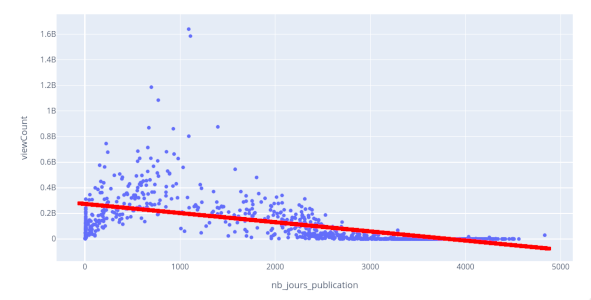

À l'oeil, personnellement, j'aurais envie de dessiner une courbe un peu plus complexe qu'une droite (j'ai fait ce beau dessin à la main) :

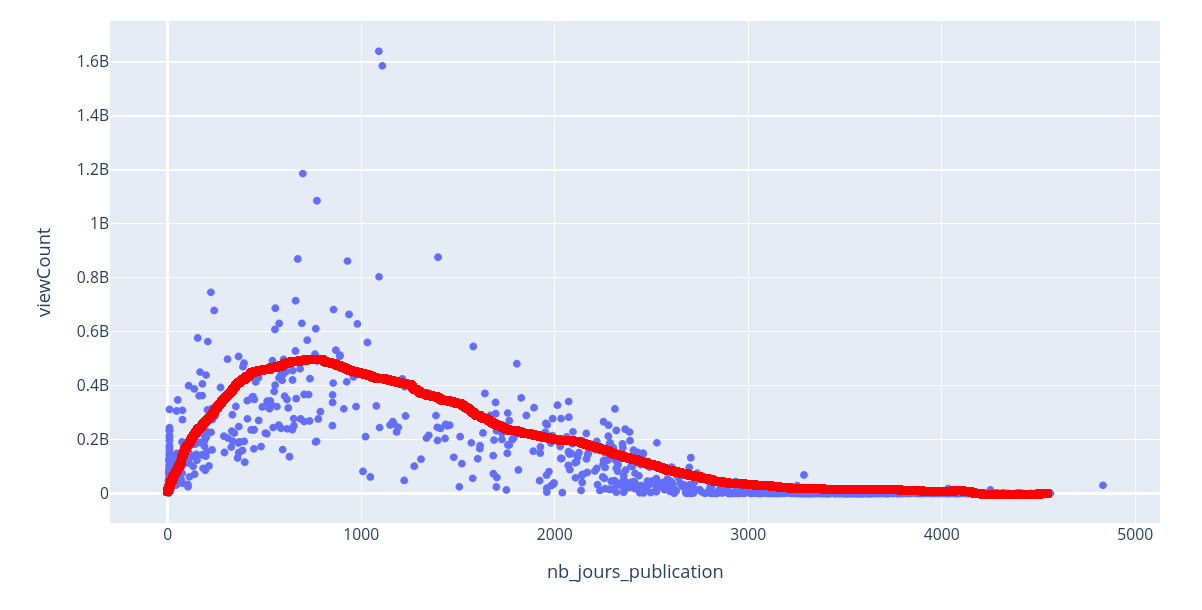


Une relation **non-linéaire** ferait possiblement plus de sens ici. Les données sont plus compliquées qu'une droite.

### Truc : régression linéaire sur des caractéristiques transformées

La formule générale d'une régression linéaire est :

$$y = m_1 \text{variable}_1 + m_2  \text{variable}_2 + ... + m_N  \text{variable}_N + b$$

On pourrait abuser de cette forme en reprenant la même variable, mais transformée de différentes façons, par exemple :

$$\text{views} = + m_1 \text{likes}^2  + m_2 \text{likes} + b$$

Ce qui correspond plutôt à une fonction **polynômiale** :

$$y = a x^2 + b x + c$$

Ici spécifiquement, ça correspondrait à un polynôme de degré 2.

&nbsp;

**Reformulons** : si on fait une régression *linéaire* à travers un polynôme de degré 2 construit à partir du nombre de likes, ce qu'on est en train de faire en réalité, c'est de trouver *la courbe quadratique qui passe le plus proche des likes*.

Une courbe quadratique, c'est quelque chose qui a l'air de :

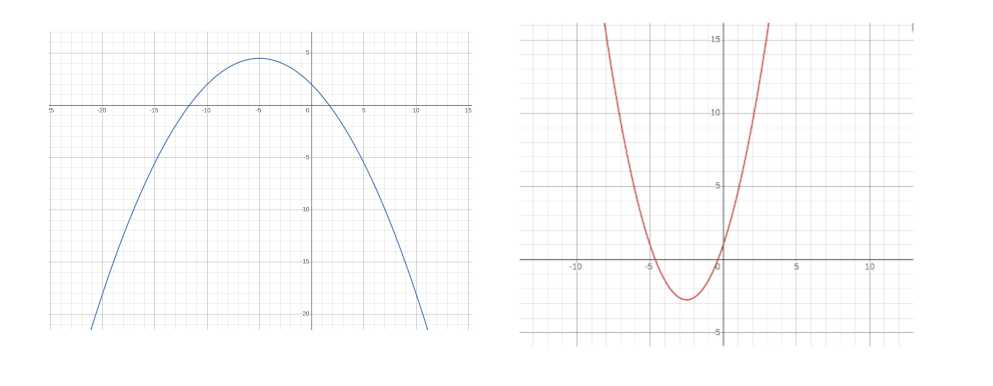

Ce qui ressemble déjà un peu plus à notre graphique du `jours_passes`...

**QUESTION 6**

Complétez la fonction `ajouter_colonnes()`, qui doit ajouter des colonnes basées sur `jours_passes2`, mais avec des exposants de plus en plus grands.

In [ ]:
#@title Exercice 6

df_mr_beast_jours = df_mr_beast_nettoye2[['viewCount', 'jours_passes']]

def ajouter_colonnes(df, exposant):
  # TODO: Retourner un DataFrame qui contient des colonnes supplémentaires
  # qui correspondent au nombre de jours depuis la publication de la vidéo (jours_passes),
  # mais exposant 2, exposant 3, ... jusqu'au chiffre passé dans exposant
  # Inspirez-vous de la syntaxe suivante:
  nom_colonne = "jours_passes2"
  df = df.assign(**{nom_colonne: df.jours_passes})
  return df # TODO


############


##### tests

# Lignes à ajouter au DataFrame d'erreurs
erreurs_rmse = []

for exposant in range(1, 7):
  print("=== Polynôme de degré", exposant, "===")
  df_jours_polynomial = ajouter_colonnes(df_mr_beast_jours, exposant)

  modele = LinearRegression()
  rmse_entrainement_jours_polynomial, rmse_validation_jours_polynomial = entrainer_et_evaluer(modele, df_jours_polynomial, 'viewCount')
  print("RMSE (entrainement):", rmse_entrainement_jours_polynomial)
  print("RMSE (validation):", rmse_validation_jours_polynomial)

  erreurs_rmse.append(['RMSE entrainement', 'jours_' + str(exposant), rmse_entrainement_jours_polynomial]),
  erreurs_rmse.append(['RMSE validation', 'jours_' + str(exposant), rmse_validation_jours_polynomial]),


  # Affichage de la fonction apprise
  X_visualisation = pd.DataFrame(np.linspace(0, 4000, 4000).reshape(4000, 1), columns=['jours_passes'])
  X_visualisation = ajouter_colonnes(X_visualisation, exposant)
  y_visualisation = modele.predict(X_visualisation)

  fig1 = px.scatter(
      X_visualisation.assign(predictions=y_visualisation),
      x="jours_passes", y="predictions", color_discrete_sequence=["hotpink"])
  fig2 = px.scatter(df_jours_polynomial, x="jours_passes", y="viewCount")
  fig = Figure(data=fig1.data + fig2.data)
  fig.update_layout(
      title="Régression sur le nombre de jours -- polynôme de degré " + str(exposant),
      xaxis=dict(title="jours_passes"),
      yaxis=dict(title="viewCount"),
  )
  display(fig)


df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'moyenne', 173679199.9725637],
    ['RMSE validation', 'moyenne', 171331992.15606025],
    ['RMSE entrainement', 'médiane', 192136092.6042148],
    ['RMSE validation', 'médiane', 189253847.1924013],
] + erreurs_rmse, columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')



Vous devriez voir que l'erreur de validation est la plus faible quand on utilise **un polynôme de degré 4**.

L'erreur recommence à monter après ça.

*Ce qu'on vient de faire ici est également décrit rapidement dans le Guide Méthodologique pour les sciences expérimentales. En complément à cette section, vous pouvez vous référer à la section 5.3.2 - Linéarisation par changement de variable.*

**QUESTION 7**

Combinez toute l'information qui améliorait notre modèle :

- `likeCount`
- `commentCount`
- Polynôme de degré 4 sur les `jours_passes`

In [ ]:
#@title Exercice 7

df_mr_beast_complet = ... # Sortez toutes les colonnes intéressantes de df_mr_beast_nettoye2

#########

### Ajoutez ensuite jours_passes^2, jours_passes^3, jours_passes^4

#### tests
modele = LinearRegression()
rmse_entrainement_jours_polynomial, rmse_validation_jours_polynomial = entrainer_et_evaluer(modele, df_mr_beast_complet, 'viewCount')
print("RMSE (entrainement):", rmse_entrainement_jours_polynomial)
print("RMSE (validation):", rmse_validation_jours_polynomial)

df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'moyenne', 173679199.9725637],
    ['RMSE validation', 'moyenne', 171331992.15606025],
    ['RMSE entrainement', 'médiane', 192136092.6042148],
    ['RMSE validation', 'médiane', 189253847.1924013],
    ['RMSE entrainement', 'comments', 155512523.0071754],
    ['RMSE validation', 'comments', 166059126.57450733],
    ['RMSE entrainement', 'likes', 72069347.63688974],
    ['RMSE validation', 'likes', 78923688.25563353],
    ['RMSE entrainement', '2cols', 72078379.66888389],
    ['RMSE validation', '2cols', 76038378.49578053],
    ['RMSE entrainement', '3cols', 70053544.85598968],
    ['RMSE validation', '3cols', 71313231.38761766],
    ['RMSE entrainement', 'complet', rmse_entrainement_jours_polynomial],
    ['RMSE validation', 'complet', rmse_validation_jours_polynomial],
], columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')



🎉 L'erreur continue de descendre!

Vous devriez finir avec un modèle qui a une erreur **RMSE de validation de ≈63.3M**.

## Test final

In [14]:
#@title Estimation finale de l'erreur sur le jeu de données de test

# ======== Préparation du jeu de données final ========
df_mr_beast_nettoye_final = df_mr_beast_test_final[['viewCount', 'likeCount', 'commentCount', 'pull_date', 'publishTime']]
df_mr_beast_nettoye_final = df_mr_beast_nettoye_final.assign(
    pull_date=pd.to_datetime(df_mr_beast_nettoye_final.pull_date),
    publishTime=pd.to_datetime(df_mr_beast_nettoye_final.publishTime))
df_mr_beast_nettoye_final = df_mr_beast_nettoye_final.dropna()
jours_passes = []
for idx, ligne in df_mr_beast_nettoye_final.iterrows():
  deltaTemps = ligne.pull_date - ligne.publishTime
  jours_passes.append(deltaTemps.days)
df_mr_beast_nettoye_final = df_mr_beast_nettoye_final.assign(jours_passes=jours_passes)
df_mr_beast_nettoye_final = df_mr_beast_nettoye_final.drop(['pull_date', 'publishTime'], axis='columns')

def ajouter_colonnes(df, exposant):
  for i in range(1, exposant+1):
    nom_colonne = "jours_passes" + str(i)
    df = df.assign(**{nom_colonne: df.jours_passes**i})
  return df

df_mr_beast_final_test = df_mr_beast_nettoye_final[['viewCount', 'likeCount', 'commentCount', 'jours_passes']]
df_mr_beast_final_test = ajouter_colonnes(df_mr_beast_final_test, 4)

df_mr_beast_final_entrainement = df_mr_beast_nettoye2[['viewCount', 'likeCount', 'commentCount', 'jours_passes']]
df_mr_beast_final_entrainement = ajouter_colonnes(df_mr_beast_final_entrainement, 4)

modele_evaluation_finale = LinearRegression()

modele_evaluation_finale.fit(
    df_mr_beast_final_entrainement.drop('viewCount', axis='columns'),
    df_mr_beast_final_entrainement['viewCount'])
y_predictions = modele_evaluation_finale.predict(df_mr_beast_final_test.drop('viewCount', axis='columns'))

print("RMSE (test final):", root_mean_squared_error(y_predictions, df_mr_beast_final_test['viewCount']))

RMSE (test final): 67971547.57504345


L'erreur RMSE finale obtenue est plutôt de **67.9M**.

On remarque que c'est un peu plus haut que l'estimation qu'on avait initialement, donc que le modèle est légèrement moins bon avec des nouvelles données.

La toute dernière étape ici serait de réentraîner le modèle encore une dernière fois, mais avec **tout le jeu de données**.

On aurait notre estimateur final de views de vidéos de Mr.Beast, prêt à être utilisé dans le vrai monde.

# Pousser ça plus loin

Il y a encore beaucoup de choses qu'on pourrait dire sur le sujet...

- Est-ce que l'erreur RMSE est la meilleure façon de juger de notre résultat?
  - Est-ce qu'une erreur de +67.8M sur une vidéo à 995M de vues, c'est aussi grave qu'une erreur de +67.8M sur une vidéo de 50M de vues?
- Est-ce qu'on peut continuer d'ajouter de l'information de notre jeu de données? Quand on zoom un peu, on peut avoir l'impression que les données plus basses suivent une courbe qui ressemble plus à une racine carrée (en vert) qu'à une vraie droite (en rouge)...

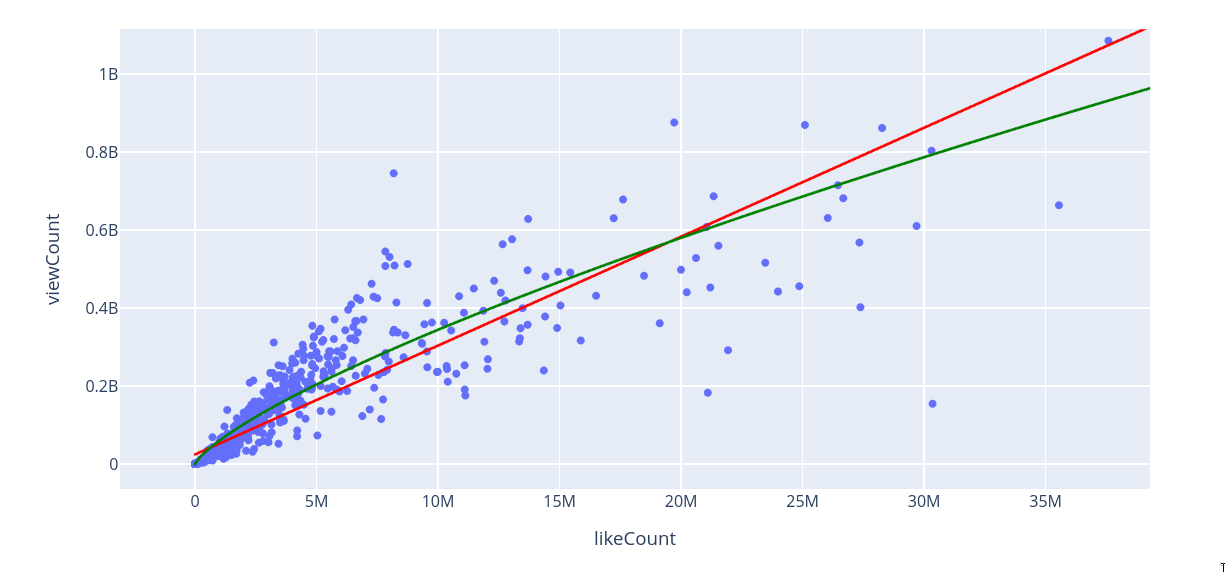


Bref, on pourrait continuer encore un certain temps sur cet exercice, mais on va passer à autre chose dans le prochain module.

# En résumé

- Pour choisir le meilleur *et* avoir une bonne idée de son erreur de prédiction, on doit **séparer notre jeu de données en trois**
    - Entraînement : les données fournies à l'algorithme pour apprendre des paramètres
    - Validation : des données utilisées pour estimer l'erreur avec un choix de modèle donné
    - Test final : des données gardées pour la toute fin, une fois qu'on a choisir le modèle qui nous intéresse
- En général...
  - **L'erreur d'entraînement** risque d'être la plus basse (car on a utilisé ces données pour apprendre les paramètres)
  - **L'erreur de validation** sera souvent un peu plus élevé que l'erreur d'entraînement (car ce sont des données qui n'ont pas été utilisées pendant l'entraînement)
  - **L'erreur de test final** sera souvent un peu plus élevée que l'erreur de validation, car on a des chances d'avoir introduit un biais en faveur de certaines données en regardant le score de validation pour sélectionner le modèle
- On peut généraliser la régression à **plusieurs variables** : la régression linéaire multiple
    - 1 variable = trouver une droite dans nos points
    - 2 variables = trouver un plan
    - 3+ variables = trouver un hyperplan
- Pour améliorer les résultats, on peut **tenter d'ajouter des données et voir si ça aide**
- Les données doivent être **numériques** : si on a du texte, on doit trouver une façon de le transformer en nombre (ex.: convertir une date en nombre de jours)
- Si nos données suivent un motif plus complexe qu'une droite, on peut faire une **régression non-linéaire** (*ie*, apprendre une fonction plus complexe qu'une droite) en transformant les données et en faisant une régression linéaire quand même.
    - Ça nous permet d'apprendre à décrire les données par un polynôme arbitraire, ou par n'importe quelle structure de fonction choisie au préalable.